In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

🔍 Step 1: Auditing Local Data Footprint...
✅ Loaded Sample Well Path: 000d7d20__horizontal_well.csv
   🔹 Horizontal Log Shape: (5278, 13) | Columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']
   🔹 Vertical Typewell Shape: (1296, 3) | Columns: ['TVT', 'GR', 'Geology']

📊 LAUNCHING STRUCTURAL EDA VISUALIZATIONS...


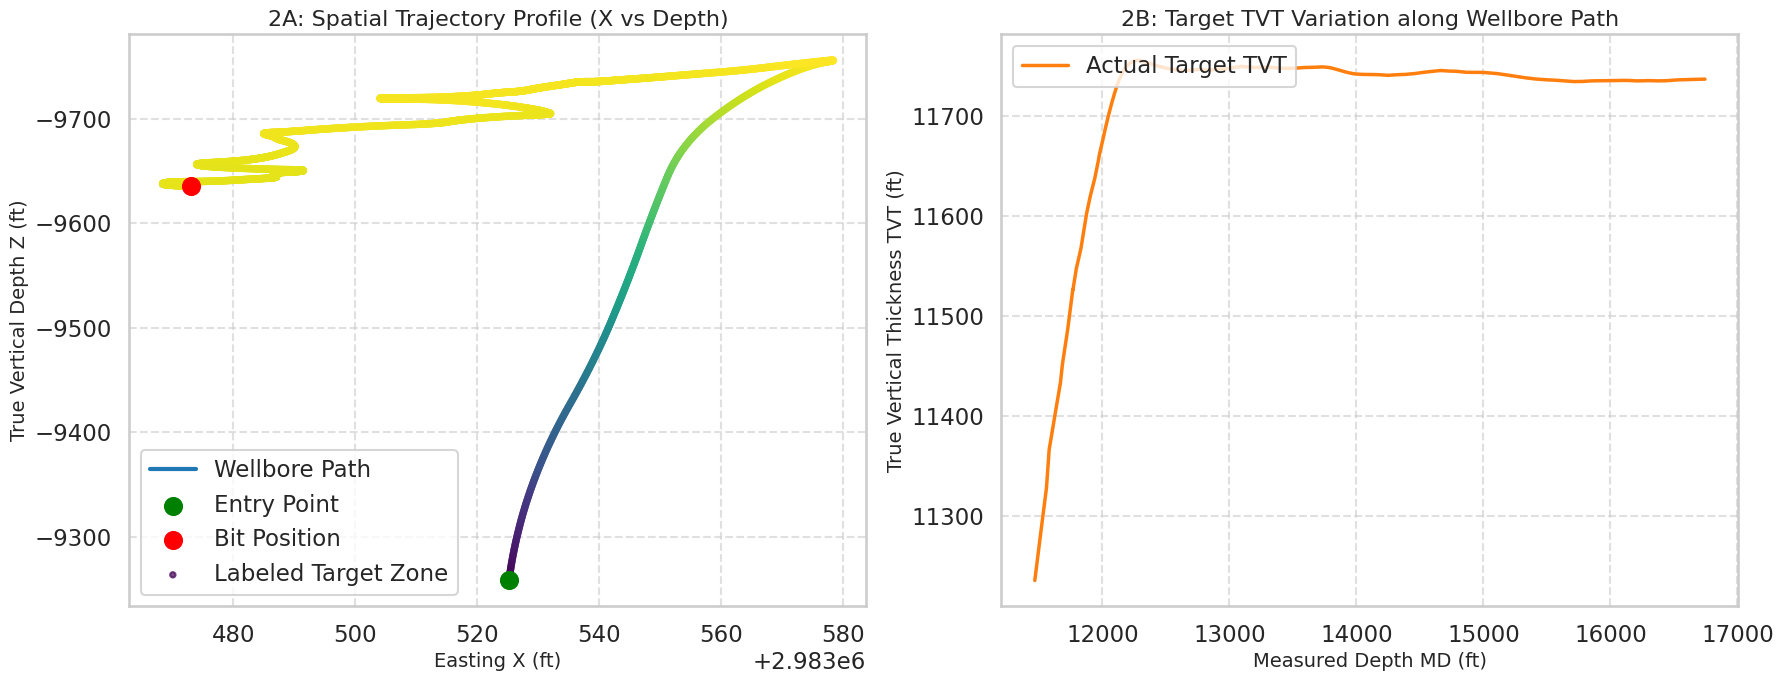

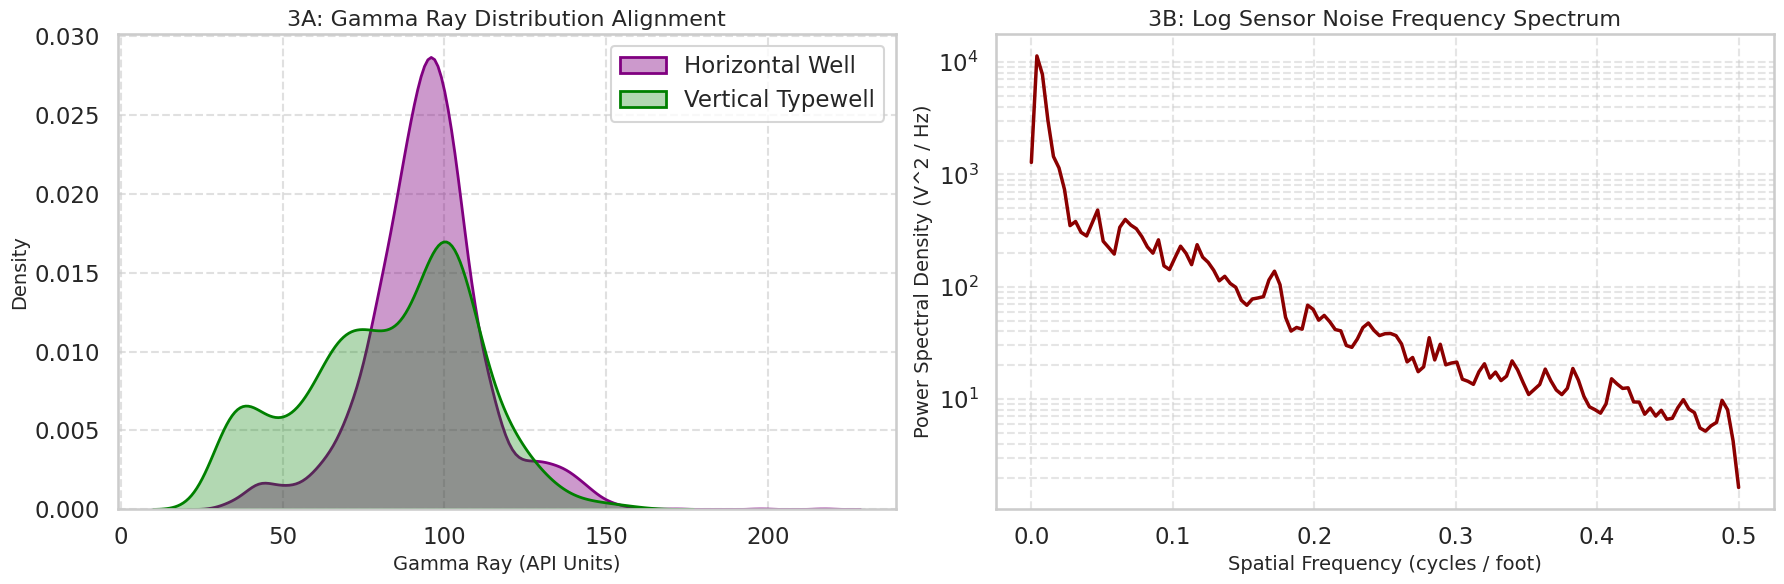


📈 GENERATING MACRO GEOLOGICAL STATISTICAL METRICS...
📋 Summary Matrix Table across Geosteering Baselines:
                    mean          std           min           max
tvt_mean    11449.828556   647.880951  10267.642728  12732.040675
tvt_std       131.760967    42.827705     42.126305    222.899947
tvt_min     10798.722750   669.349407   9556.520000  12192.180000
tvt_max     11511.094500   648.338528  10326.130000  12837.980000
total_rows   6425.950000  1147.442260   4430.000000   9182.000000
eval_rows       0.000000     0.000000      0.000000      0.000000


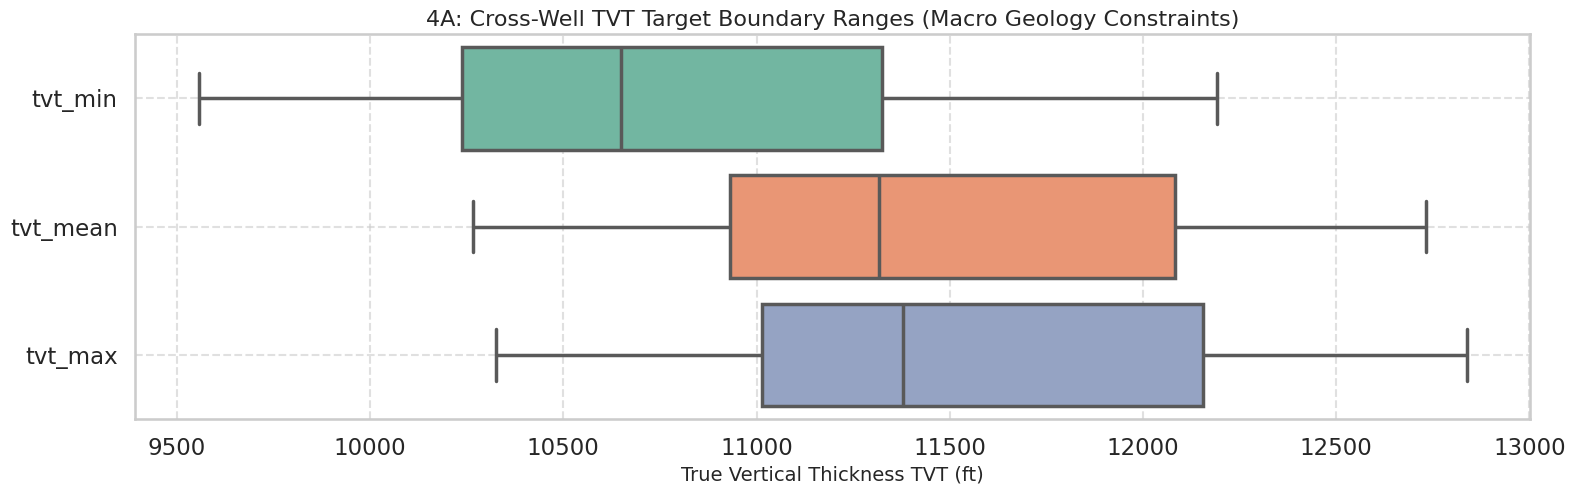

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import welch

# Set plotting aesthetics for high-fidelity geostatistical analysis
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

# ==============================================================================
# 1. PATH RESOLUTION & AUDITING
# ==============================================================================
print("🔍 Step 1: Auditing Local Data Footprint...")

COMP_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
TRAIN_DIR = os.path.join(COMP_DIR, 'train')

train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, '*horizontal_well.csv')))
if not train_files:
    train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, '*', '*horizontal_well.csv')))

assert len(train_files) > 0, "❌ No training files discovered. Please verify dataset mounting."

# Load a representative sample well for deep inspection
sample_hw_path = train_files[0]
sample_tw_path = sample_hw_path.replace("__horizontal_well.csv", "__typewell.csv") if "__horizontal" in sample_hw_path else sample_hw_path.replace("_horizontal_well.csv", "_typewell.csv")

df_hw = pd.read_csv(sample_hw_path)
df_tw = pd.read_csv(sample_tw_path) if os.path.exists(sample_tw_path) else None

print(f"✅ Loaded Sample Well Path: {Path(sample_hw_path).name}")
print(f"   🔹 Horizontal Log Shape: {df_hw.shape} | Columns: {list(df_hw.columns)}")
if df_tw is not None:
    print(f"   🔹 Vertical Typewell Shape: {df_tw.shape} | Columns: {list(df_tw.columns)}")

print("\n" + "="*80 + "\n📊 LAUNCHING STRUCTURAL EDA VISUALIZATIONS...\n" + "="*80)

# ==============================================================================
# 2. STRUCTURAL GEOMETRY & TRAJECTORY PROFILE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 2A: 3D Trajectory Projection Plane (X vs Z/Depth)
df_hw.columns = [c.upper().strip() for c in df_hw.columns]
depth_col = next((c for c in ['Z', 'TVDSS', 'TVD', 'DEPTH'] if c in df_hw.columns), None)

if depth_col and 'X' in df_hw.columns:
    axes[0].plot(df_hw['X'], df_hw[depth_col], color='#1f77b4', lw=3, label='Wellbore Path')
    axes[0].scatter(df_hw['X'].iloc[0], df_hw[depth_col].iloc[0], color='green', s=150, zorder=5, label='Entry Point')
    axes[0].scatter(df_hw['X'].iloc[-1], df_hw[depth_col].iloc[-1], color='red', s=150, zorder=5, label='Bit Position')
    
    # Highlight known TVT labels vs evaluation blind gap zones
    if 'TVT' in df_hw.columns:
        known_mask = df_hw['TVT'].notna()
        axes[0].scatter(df_hw.loc[known_mask, 'X'], df_hw.loc[known_mask, depth_col], 
                         c=df_hw.loc[known_mask, 'TVT'], cmap='viridis', s=15, alpha=0.7, zorder=3, label='Labeled Target Zone')
        
    axes[0].invert_yaxis()  # Subsurface depths increase downwards
    axes[0].set_title("2A: Spatial Trajectory Profile (X vs Depth)")
    axes[0].set_xlabel("Easting X (ft)")
    axes[0].set_ylabel("True Vertical Depth Z (ft)")
    axes[0].legend(loc='lower left', frameon=True)
    axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2B: Continuous Target TVT Profile along Measured Depth (MD)
if 'MD' in df_hw.columns and 'TVT' in df_hw.columns:
    axes[1].plot(df_hw['MD'], df_hw['TVT'], color='#ff7f0e', lw=2.5, label='Actual Target TVT')
    
    # Draw background span indicating the missing evaluation target zones
    nan_mask = df_hw['TVT'].isna()
    if nan_mask.any():
        nan_mds = df_hw.loc[nan_mask, 'MD']
        axes[1].axvspan(nan_mds.min(), nan_mds.max(), color='red', alpha=0.15, label='Blind Target Eval Zone')
        
    axes[1].set_title("2B: Target TVT Variation along Wellbore Path")
    axes[1].set_xlabel("Measured Depth MD (ft)")
    axes[1].set_ylabel("True Vertical Thickness TVT (ft)")
    axes[1].legend(loc='upper left', frameon=True)
    axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. LITHOLOGICAL SIGNAL CORRELATION & FREQUENCY SPECTRA
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 3A: Distribution density profiles of Gamma Ray (GR) sensors
if 'GR' in df_hw.columns:
    sns.kdeplot(df_hw['GR'].dropna(), ax=axes[0], fill=True, color='purple', alpha=0.4, lw=2, label='Horizontal Well')
    if df_tw is not None and 'GR' in df_tw.columns:
        sns.kdeplot(df_tw['GR'].dropna(), ax=axes[0], fill=True, color='green', alpha=0.3, lw=2, label='Vertical Typewell')
        
    axes[0].set_title("3A: Gamma Ray Distribution Alignment")
    axes[0].set_xlabel("Gamma Ray (API Units)")
    axes[0].set_ylabel("Density")
    axes[0].legend(frameon=True)
    axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 3B: Power Spectral Density (PSD) analysis to measure High-Frequency Noise
if 'GR' in df_hw.columns:
    gr_signal = df_hw['GR'].interpolate(method='linear').fillna(100.0).values
    frequencies, psd = welch(gr_signal, fs=1.0, nperseg=min(256, len(gr_signal)))
    
    axes[1].semilogy(frequencies, psd, color='darkred', lw=2.5)
    axes[1].set_title("3B: Log Sensor Noise Frequency Spectrum")
    axes[1].set_xlabel("Spatial Frequency (cycles / foot)")
    axes[1].set_ylabel("Power Spectral Density (V^2 / Hz)")
    axes[1].grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. MACRO-GEOLOGICAL STATISTICAL PROFILE
# ==============================================================================
print("\n" + "="*80 + "\n📈 GENERATING MACRO GEOLOGICAL STATISTICAL METRICS...\n" + "="*80)

# Compute macro properties across multiple files to identify target variance patterns
well_stats = []
for filepath in train_files[:40]:  # Read top 40 wells to construct structural sample metrics
    df = pd.read_csv(filepath)
    df.columns = [c.upper().strip() for c in df.columns]
    
    if 'TVT' in df.columns:
        tvt_valid = df['TVT'].dropna()
        if len(tvt_valid) > 0:
            well_stats.append({
                'well_id': os.path.basename(filepath).split('_')[0],
                'tvt_mean': tvt_valid.mean(),
                'tvt_std': tvt_valid.std(),
                'tvt_min': tvt_valid.min(),
                'tvt_max': tvt_valid.max(),
                'total_rows': len(df),
                'eval_rows': df['TVT'].isna().sum()
            })

df_stats = pd.DataFrame(well_stats)

print("📋 Summary Matrix Table across Geosteering Baselines:")
print(df_stats.describe().T[['mean', 'std', 'min', 'max']])

# Plot 4A: Inter-Well Boxplot Distribution Stability
plt.figure(figsize=(18, 5))
sns.boxplot(data=df_stats[['tvt_min', 'tvt_mean', 'tvt_max']], palette='Set2', orient='h', linewidth=2.5)
plt.title("4A: Cross-Well TVT Target Boundary Ranges (Macro Geology Constraints)")
plt.xlabel("True Vertical Thickness TVT (ft)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()